###1-SVM-Basics
- make_blobs() generates datasets automatically.
- Think of it as a dataset generator.
- It creates clusters of points.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

from sklearn.svm import SVC

###Generate Dataset
#### n_samples=100

- Means:

- Create 100 data points.

####centers=2

- Means:

- Create 2 classes.

####cluster_std=1.2

- This controls how spread out each cluster is.
- The larger the value, the harder the classification problem becomes.

In [2]:
X, y = make_blobs(
    n_samples=100,
    centers=2,
    random_state=42,
    cluster_std=1.2
)

###Visualize the Dataset
- plt.scatter()

This draws a scatter plot.


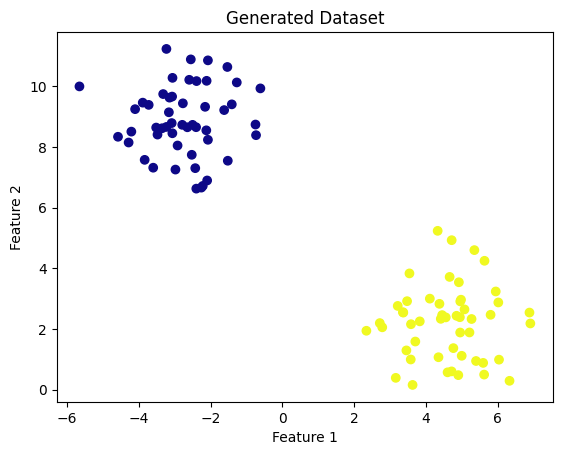

In [5]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="plasma")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated Dataset")

plt.show()

###Train Your First SVM

####What is SVC?

####SVC stands for:

- Support Vector Classifier

####Remember:

- SVM = Support Vector Machine (the algorithm)
- SVC = Scikit-learn's implementation for classification

- If we were predicting house prices (regression), we'd use SVR (Support Vector Regressor).

###kernel="linear"

####This tells SVM:

- se a linear kernel.

- Since our generated data is linearly separable, a straight hyperplane is enough.

In [9]:
model = SVC(kernel="linear")

model.fit(X, y)

SVC(kernel='linear')

In [8]:
"""
        X + y
          │
          ▼
      model.fit()
          │
          ▼
Find the best hyperplane
          │
          ▼
Maximize the margin
          │
          ▼
Identify support vectors
          │
          ▼
Model is trained ✅
"""

'\n        X + y\n          │\n          ▼\n      model.fit()\n          │\n          ▼\nFind the best hyperplane\n          │\n          ▼\nMaximize the margin\n          │\n          ▼\nIdentify support vectors\n          │\n          ▼\nModel is trained ✅\n'

###Make Predictions

In [10]:
predictions = model.predict(X)

print(predictions)

[0 1 0 1 1 0 1 1 0 0 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 0 0 0 0 0 1 1
 0 0 0 0 1 1 1 1 0 0 0 0 1 1 0 0 1 0 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 0 1 1 1
 1 1 1 0 1 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0]


###See the Support Vectors

In [11]:
print("Support Vectors:")
print(model.support_vectors_)

Support Vectors:
[[-0.73572477  8.39236187]
 [ 4.32229064  5.23737268]]


###Visualizing the SVM
####That means:

- Class 0 has 1 support vectors
- Class 1 has 1 support vectors
- Total = 2 support vectors

In [13]:
print("Number of Support Vectors:")
print(model.n_support_)

Number of Support Vectors:
[1 1]


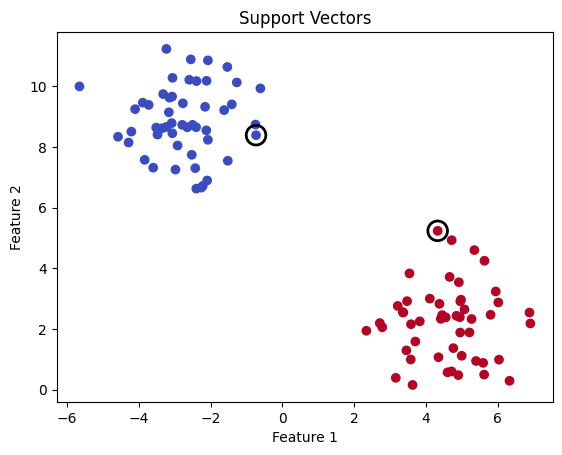

In [14]:
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm"
)

plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=200,
    facecolors="none",
    edgecolors="black",
    linewidth=2
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Support Vectors")

plt.show()

###Drawing the Decision Boundary

###Understand the Equation
**The hyperplane is:**

- w1x1+w2x2+b=0

- w = Weights (slope/orientation)

- b = Bias (shift)

- x = Features

###Print the Weights

In [15]:
print("Weights:")
print(model.coef_)

print("Bias:")
print(model.intercept_)

Weights:
[[ 0.28465809 -0.17755842]]
Bias:
[0.69956454]


###Draw the Hyperplane

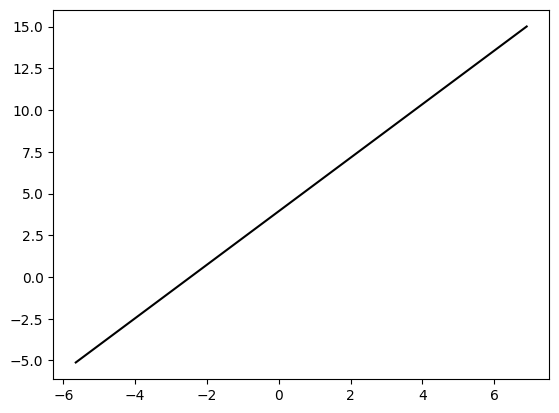

In [16]:
w = model.coef_[0]
b = model.intercept_[0]

x_points = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

y_points = -(w[0] * x_points + b) / w[1]

plt.plot(x_points, y_points, color="black", label="Decision Boundary")

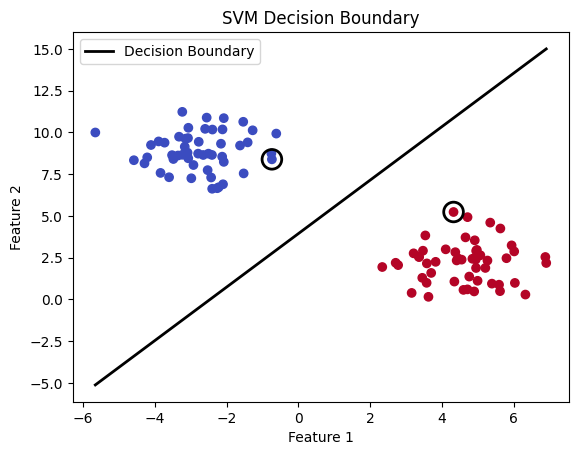

In [17]:
# Plot dataset
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm"
)

# Plot support vectors
plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=200,
    facecolors="none",
    edgecolors="black",
    linewidth=2
)

# Decision Boundary
w = model.coef_[0]
b = model.intercept_[0]

x_points = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

y_points = -(w[0] * x_points + b) / w[1]

plt.plot(
    x_points,
    y_points,
    color="black",
    linewidth=2,
    label="Decision Boundary"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Decision Boundary")
plt.legend()

plt.show()

###draw the margins
Upper Margin
##----------------------

Decision Boundary
##======================

Lower Margin
##----------------------

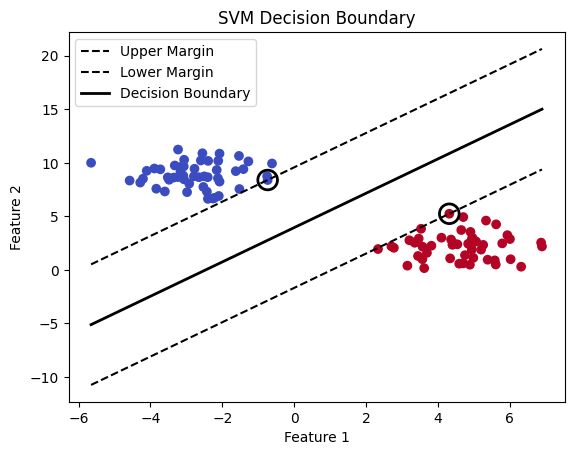

In [20]:
# Plot dataset
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm"
)

# Plot support vectors
plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=200,
    facecolors="none",
    edgecolors="black",
    linewidth=2
)

# Decision Boundary
w = model.coef_[0]
b = model.intercept_[0]

x_points = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

y_points = -(w[0] * x_points + b) / w[1]

#Add these lines after y_points

margin = 1 / np.sqrt(np.sum(w ** 2))

y_margin_up = y_points + np.sqrt(1 + (w[0] / w[1]) ** 2) * margin

y_margin_down = y_points - np.sqrt(1 + (w[0] / w[1]) ** 2) * margin

#Now plot them:
plt.plot(
    x_points,
    y_margin_up,
    "k--",
    label="Upper Margin"
)

plt.plot(
    x_points,
    y_margin_down,
    "k--",
    label="Lower Margin"
)

plt.plot(
    x_points,
    y_points,
    color="black",
    linewidth=2,
    label="Decision Boundary"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Decision Boundary")
plt.legend()

plt.show()